# Bayesian Inference in ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply basic Bayesian inference
- Update priors with likelihood; interpret posteriors
- Connect Bayesian ideas to ML (e.g. uncertainty)

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 04 "Probabilistic Reasoning: Bayes' Theorem" — prior, likelihood and posterior for single events; here the same rule updates whole distributions.

**Used later in:** Course 04 (AIAT 114) — Unit 3, lesson 05 "Random Forest and Naive Bayes Classifiers" — a classifier built entirely out of this rule.

---


---

## 📌 Real case: 160 doctors and one positive mammogram

Gerd Gigerenzer, Wolfgang Gaissmaier, Elke Kurz-Milcke, Lisa Schwartz and Steven Woloshin put the
following to **160 practising gynaecologists** (reported in *"Helping Doctors and Patients Make Sense of
Health Statistics"*, Psychological Science in the Public Interest, 2007):

> The probability that a woman has breast cancer is **1%**. If she has breast cancer, the probability that
> she tests positive on a mammogram is **90%**. If she does not have breast cancer, the probability that
> she nevertheless tests positive is **9%**. A woman tests positive. What is the chance she has cancer?

The correct answer is **about 1 in 10**. Out of 1,000 women, 10 have cancer and 9 of them test positive;
990 do not have cancer and about 89 of them test positive anyway — so roughly 9 of 98 positives are real.
Before training, **only 21% of the doctors found the best answer** — worse than guessing among the options
offered. The majority answered "90%" or "81%", confusing the probability of a positive test *given* cancer
with the probability of cancer *given* a positive test. After being taught to convert the percentages into
natural frequencies, **87% got it right**.

**What goes wrong without this.** These are specialists, reading a test they order every day, off by a
factor of nine — in the direction that causes unnecessary biopsies and terrified patients. The error is
not arithmetic. It is forgetting the **prior**: cancer is rare, so most positives come from the enormous
healthy group. Every classifier you deploy on a rare event has exactly this structure, and its precision
will disappoint you for exactly this reason.


# Bayesian Inference in ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 2: Statistical Inference** - Understand hypothesis testing
- ✅ **Basic understanding**: What is Bayesian inference?

**If you haven't completed these**, you might struggle with:
- Understanding Bayesian vs frequentist
- Understanding prior and posterior
- Applying Bayesian methods

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 05** - advanced inference!

**Why this example THIRD?**
- **Before** you can understand Bayesian methods, you need frequentist methods (Example 2)
- **Before** you can use Bayesian ML, you need Bayesian inference

**Builds on**: Example 2 (statistical inference)

**Leads to**: Advanced ML topics

---

## The Story: Understanding Before Using

Imagine updating your beliefs as you learn. **Before** you have prior beliefs. **After** seeing data, you update to posterior beliefs. This is Bayesian inference!

Same with machine learning: **Before** training, we have prior beliefs about parameters. **After** seeing data, we update to posterior beliefs using Bayesian inference!

---

## Why This Concept Matters

### Why Bayesian Inference Matters

**WHY** is Bayesian inference important?

1. **Prior Knowledge**:
   - **WHY**: Can incorporate prior knowledge
   - **HOW**: Use prior distributions
   - **AFTER**: Better use of information

2. **Uncertainty Quantification**:
   - **WHY**: Provides full uncertainty distribution
   - **HOW**: Compute posterior distribution
   - **AFTER**: Better uncertainty estimates

3. **Regularization**:
   - **WHY**: Priors act as regularization
   - **HOW**: Prior constrains parameters
   - **AFTER**: Better generalization

## Learning Objectives
1. Understand Bayesian inference
2. Understand prior and posterior
3. Apply to ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

---

## 🌉 Bridge: The Ingredients — Bernoulli/Binomial, Likelihood, and Beta

The example below uses three terms this unit has not formally introduced yet. Working definitions (the binomial reappears in notebook 06, where **likelihood** gets its full treatment):

1. **Bernoulli / binomial model.** A Bernoulli trial is a single yes/no outcome with success probability p (one free throw, one click). Repeat n independent trials and count the successes k: that count follows the **binomial distribution**.
2. **Likelihood.** For observed data "k successes in n trials", the probability of that data for a candidate p is P(data | p) = C(n,k) · pᵏ(1−p)ⁿ⁻ᵏ. Read as a function of p, this is the **likelihood**: it scores how well each candidate p explains the data.
3. **Beta distribution.** A distribution over p itself (values in [0, 1]) with shape parameters α and β — think "α−1 successes and β−1 failures already believed in". It is the natural **prior** for a probability.

**Why Beta + binomial pair so well (conjugacy):** multiply a Beta(α, β) prior by a binomial likelihood with k successes in n trials, and the posterior is again a Beta — **Beta(α + k, β + n − k)**. Updating beliefs becomes simple addition. The next cell shows the ingredients separately before we combine them.

Data: 8 successes in 10 trials
Likelihood peaks at p ≈ 0.80 (= k/n = 0.80)


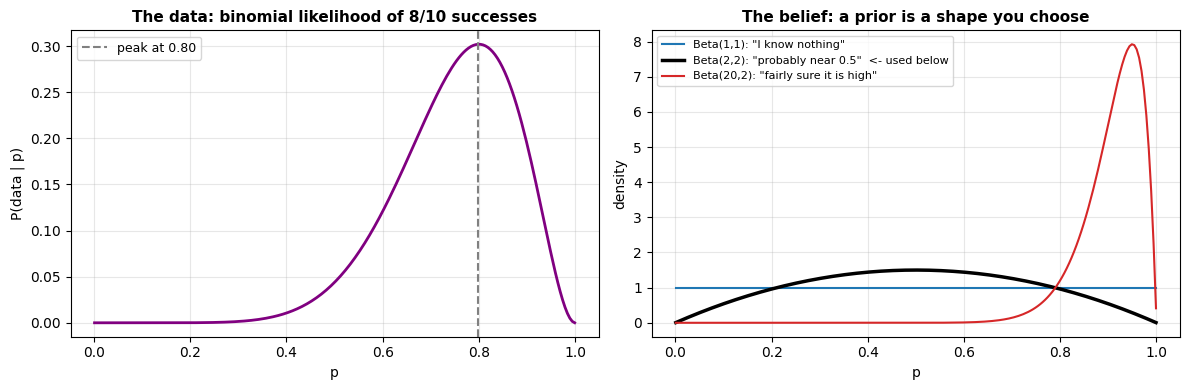


📊 Read the figure:
  - Left: the likelihood is highest at p = 0.80 and is NOT a probability
    distribution over p - it is a score for each candidate p, given fixed data.
  - Right: all three curves are legal priors over the same p. The flat blue one adds
    nothing, the black one leans gently towards 0.5, the red one insists p is high.
    Choosing between them is a modelling decision, and the experiment below measures
    exactly how much that decision costs you.

Next: combine the black prior with this likelihood → a Beta posterior (conjugate update)


In [2]:
# Bridge demo: the two ingredients, shown separately before they are combined.
# LEFT  - the likelihood: what the DATA says about p.
# RIGHT - the prior: what YOU said about p before the data, and the shapes a Beta can take.
from scipy import stats

n_trials, k_successes = 10, 8
p_grid = np.linspace(0.001, 0.999, 200)

# Likelihood of "8 successes in 10 trials" as a function of p
likelihood = stats.binom.pmf(k_successes, n_trials, p_grid)
p_best = p_grid[np.argmax(likelihood)]
print(f"Data: {k_successes} successes in {n_trials} trials")
print(f"Likelihood peaks at p ≈ {p_best:.2f} (= k/n = {k_successes / n_trials:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(p_grid, likelihood, color='purple', linewidth=2)
axes[0].axvline(p_best, color='gray', linestyle='--', label=f'peak at {p_best:.2f}')
axes[0].set_title(f'The data: binomial likelihood of {k_successes}/{n_trials} successes',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('p')
axes[0].set_ylabel('P(data | p)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# A prior is a CHOICE. Three Beta shapes, so the choice is visible as a shape and not just
# a pair of numbers - the same three families reappear in the experiment further down.
shapes = [(1, 1, 'Beta(1,1): "I know nothing"', 'tab:blue', 1.5),
          (2, 2, 'Beta(2,2): "probably near 0.5"  <- used below', 'black', 2.5),
          (20, 2, 'Beta(20,2): "fairly sure it is high"', 'tab:red', 1.5)]
for a, b, label, colr, lw in shapes:
    axes[1].plot(p_grid, stats.beta.pdf(p_grid, a, b), color=colr, linewidth=lw, label=label)
axes[1].set_title('The belief: a prior is a shape you choose', fontsize=11, fontweight='bold')
axes[1].set_xlabel('p')
axes[1].set_ylabel('density')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"  - Left: the likelihood is highest at p = {p_best:.2f} and is NOT a probability")
print("    distribution over p - it is a score for each candidate p, given fixed data.")
print("  - Right: all three curves are legal priors over the same p. The flat blue one adds")
print("    nothing, the black one leans gently towards 0.5, the red one insists p is high.")
print("    Choosing between them is a modelling decision, and the experiment below measures")
print("    exactly how much that decision costs you.")
print("\nNext: combine the black prior with this likelihood → a Beta posterior (conjugate update)")


## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [3]:
# Example 1: Bayesian Inference
# WHY: Incorporate prior knowledge and quantify uncertainty
# HOW: Update prior beliefs with data to get posterior

# Simple example: Estimating a probability
# Prior: Beta distribution (conjugate prior for binomial)
alpha_prior = 2  # Prior belief
beta_prior = 2

# Data: 8 successes out of 10 trials
successes = 8
trials = 10

# Posterior: Beta(alpha_prior + successes, beta_prior + failures)
alpha_posterior = alpha_prior + successes
beta_posterior = beta_prior + (trials - successes)

# Compute posterior mean
posterior_mean = alpha_posterior / (alpha_posterior + beta_posterior)

print("Example 1: Bayesian Inference")
print("=" * 60)
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Data: {successes} successes out of {trials} trials")
print(f"Posterior: Beta({alpha_posterior}, {beta_posterior})")
print(f"Posterior mean (probability): {posterior_mean:.4f}")
print(f"\n💡 WHY: Incorporates prior knowledge")
print(f"💡 HOW: Update prior with data → posterior")
print(f"💡 AFTER: Better estimates with uncertainty!")

Example 1: Bayesian Inference
Prior: Beta(2, 2)
Data: 8 successes out of 10 trials
Posterior: Beta(10, 4)
Posterior mean (probability): 0.7143

💡 WHY: Incorporates prior knowledge
💡 HOW: Update prior with data → posterior
💡 AFTER: Better estimates with uncertainty!


### 🧪 How much does the prior actually change the answer?

Baseline: the Beta(2,2) prior above with 8 successes in 10 trials. Change one thing: the prior — from
"I know nothing" to two confident and opposite beliefs. Then change the *amount of data* instead and watch
what happens to the disagreement.

In [4]:
# Comparative experiment: four priors x three sample sizes, same observed success rate of 0.80.
# For a Beta(a, b) prior and k successes in n trials, the posterior is Beta(a+k, b+n-k),
# so the posterior mean is simply (a + k) / (a + b + n).

priors = [("Beta(1,1)   'I know nothing'",            1,  1),
          ("Beta(2,2)   'probably near 0.5'",         2,  2),
          ("Beta(20,2)  'fairly sure it is HIGH'",   20,  2),
          ("Beta(2,20)  'fairly sure it is LOW'",     2, 20)]

for n, k in [(10, 8), (100, 80), (1000, 800)]:
    means = []
    print(f"Data: {k:>4} successes in {n:>4} trials   (observed rate {k / n:.2f})")
    for name, a, b in priors:
        pm = (a + k) / (a + b + n)
        means.append(pm)
        print(f"     {name:34s} -> posterior mean {pm:.4f}")
    print(f"     {'spread between the four priors':34s} -> {max(means) - min(means):.4f}")
    print()

print("Conclusion the numbers support: with 10 trials the four priors disagree by more than half")
print("a probability point - the answer is mostly your belief. With 1,000 trials the spread is")
print("under 0.02 - the data has taken over. That is the honest summary of what a prior")
print("does: it dominates when evidence is scarce and becomes irrelevant when evidence is")
print("plentiful. The argument about 'is it subjective?' matters most exactly where you have")
print("least data - which is exactly where people most want an answer.")

Data:    8 successes in   10 trials   (observed rate 0.80)
     Beta(1,1)   'I know nothing'       -> posterior mean 0.7500
     Beta(2,2)   'probably near 0.5'    -> posterior mean 0.7143
     Beta(20,2)  'fairly sure it is HIGH' -> posterior mean 0.8750
     Beta(2,20)  'fairly sure it is LOW' -> posterior mean 0.3125
     spread between the four priors     -> 0.5625

Data:   80 successes in  100 trials   (observed rate 0.80)
     Beta(1,1)   'I know nothing'       -> posterior mean 0.7941
     Beta(2,2)   'probably near 0.5'    -> posterior mean 0.7885
     Beta(20,2)  'fairly sure it is HIGH' -> posterior mean 0.8197
     Beta(2,20)  'fairly sure it is LOW' -> posterior mean 0.6721
     spread between the four priors     -> 0.1475

Data:  800 successes in 1000 trials   (observed rate 0.80)
     Beta(1,1)   'I know nothing'       -> posterior mean 0.7994
     Beta(2,2)   'probably near 0.5'    -> posterior mean 0.7988
     Beta(20,2)  'fairly sure it is HIGH' -> posterior mean 0.802

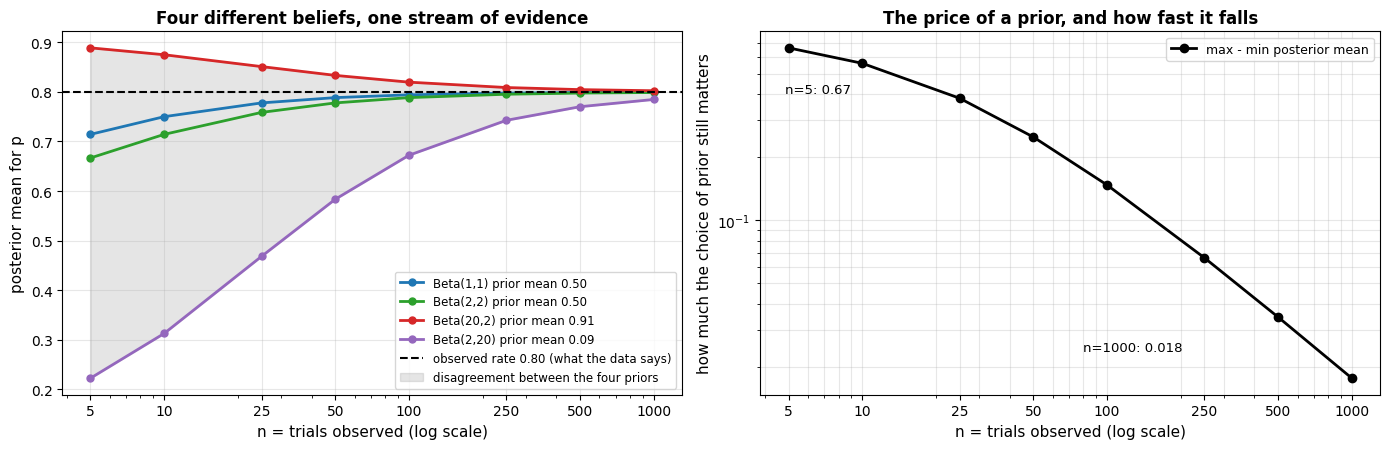


📊 Read the figure:
  - Left: four coloured lines start far apart (at n=5 they span 0.67 of probability)
    and are squeezed onto the black dashed line at 0.80 as n grows. The grey band
    between the highest and lowest line IS the disagreement, and it closes.
  - The purple 'fairly sure it is LOW' prior is the slowest to give in: at n=5 it still
    reports 0.22 while the data says 0.80.
  - Right: the same disagreement on log-log axes falls from 0.67 at n=5 to
    0.018 at n=1000 - a 38-fold shrink bought with 200x the data.
    The line falls steadily and never reaches zero: the prior always still counts for
    something, just less than the fourth decimal place of your answer.


In [5]:
# The experiment above printed a table; this draws it. The claim being tested is
# "a prior dominates when evidence is scarce and becomes irrelevant when evidence is plentiful",
# and that is a claim about a TREND, which a picture shows better than three blocks of numbers.

from scipy.stats import beta as _beta  # (already used above; imported here to keep the cell readable)

ns = np.array([5, 10, 25, 50, 100, 250, 500, 1000])
ks = (0.8 * ns).astype(int)          # same observed success rate, more and more evidence

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple']

curves = []
for (name, a, b), colr in zip(priors, colors):
    post_means = (a + ks) / (a + b + ns)
    curves.append(post_means)
    axes[0].plot(ns, post_means, 'o-', color=colr, linewidth=2, markersize=5,
                 label=f'{name.split()[0]} prior mean {a / (a + b):.2f}')
curves = np.array(curves)

axes[0].axhline(0.8, color='black', linestyle='--', linewidth=1.5,
                label='observed rate 0.80 (what the data says)')
axes[0].fill_between(ns, curves.min(axis=0), curves.max(axis=0), color='grey', alpha=0.2,
                     label='disagreement between the four priors')
axes[0].set_xscale('log')
axes[0].set_xticks(ns)
axes[0].set_xticklabels([str(v) for v in ns])
axes[0].set_xlabel('n = trials observed (log scale)', fontsize=11)
axes[0].set_ylabel('posterior mean for p', fontsize=11)
axes[0].set_title('Four different beliefs, one stream of evidence',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5)
axes[0].grid(True, alpha=0.3)

spread = curves.max(axis=0) - curves.min(axis=0)
axes[1].plot(ns, spread, 'o-', color='black', linewidth=2, markersize=6,
             label='max - min posterior mean')
# Label the two ends of the curve, inside the axes so nothing collides with the title.
axes[1].text(0.04, 0.83, f'n=5: {spread[0]:.2f}', transform=axes[1].transAxes, fontsize=9.5)
axes[1].text(0.52, 0.12, f'n=1000: {spread[-1]:.3f}', transform=axes[1].transAxes, fontsize=9.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xticks(ns)
axes[1].set_xticklabels([str(v) for v in ns])
axes[1].set_xlabel('n = trials observed (log scale)', fontsize=11)
axes[1].set_ylabel('how much the choice of prior still matters', fontsize=11)
axes[1].set_title('The price of a prior, and how fast it falls',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print(f"  - Left: four coloured lines start far apart (at n=5 they span {spread[0]:.2f} of probability)")
print("    and are squeezed onto the black dashed line at 0.80 as n grows. The grey band")
print("    between the highest and lowest line IS the disagreement, and it closes.")
print(f"  - The purple 'fairly sure it is LOW' prior is the slowest to give in: at n=5 it still")
print(f"    reports {curves[3][0]:.2f} while the data says 0.80.")
print(f"  - Right: the same disagreement on log-log axes falls from {spread[0]:.2f} at n=5 to")
print(f"    {spread[-1]:.3f} at n=1000 - a {spread[0] / spread[-1]:.0f}-fold shrink bought with {ns[-1] // ns[0]}x the data.")
print("    The line falls steadily and never reaches zero: the prior always still counts for")
print("    something, just less than the fourth decimal place of your answer.")


**📖 What to see in the figure above.** The left panel is the printed table with
its trend made visible: four confident, contradictory starting beliefs, fed the same evidence,
being dragged onto the same answer (the black dashed line at 0.80). What matters is not that
they end together but *how much data it takes* — at n = 5 the grey disagreement band is more
than half a probability point tall. The right panel measures that band directly on log–log
axes: it falls steadily, by a factor of about 38 for a 200-fold increase in evidence, and it
never quite reaches zero. Read the two together as the honest answer to "isn't a prior just an
opinion?": yes, and here is exactly how much your opinion is still worth at each sample size.

---

## 📊 Visualization

Step table: the same Beta(2,2) prior, updated by more and more evidence
frame     n     k        posterior    mean    95% credible interval   width
--------------------------------------------------------------------------
    0     0     0       Beta(2, 2)   0.500   [0.094, 0.906]      0.811
    1     5     4       Beta(6, 3)   0.667   [0.349, 0.915]      0.566
    2    10     8      Beta(10, 4)   0.714   [0.462, 0.909]      0.447
    3    25    20      Beta(22, 7)   0.759   [0.590, 0.893]      0.303
    4   100    80     Beta(82, 22)   0.788   [0.705, 0.861]      0.156
    5  1000   800   Beta(802, 202)   0.799   [0.773, 0.823]      0.050


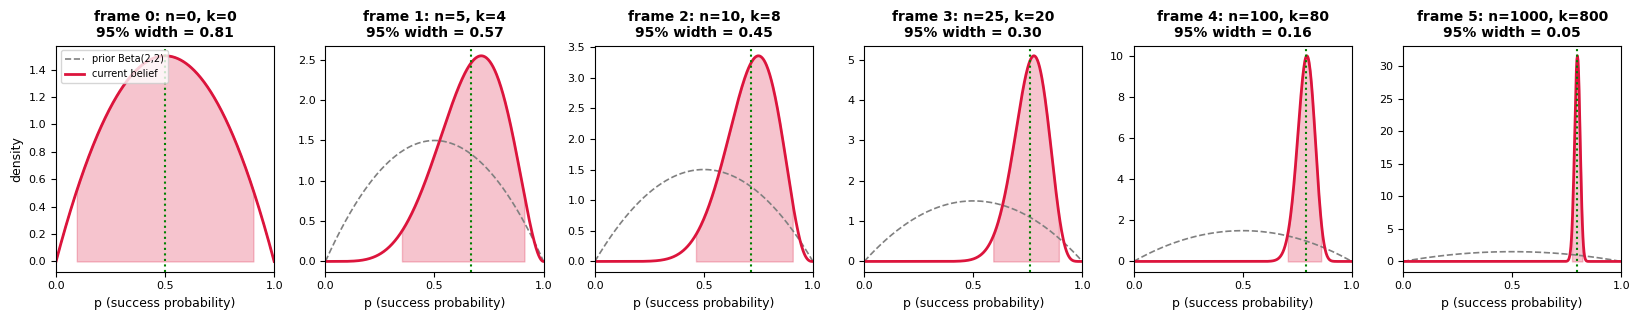


📊 Read the storyboard (left to right):
  - Grey dashed curve is the SAME Beta(2,2) prior in every frame; the crimson curve is
    the belief after that frame's evidence. Frame 0 has no data, so the two coincide.
  - The green dotted line, the posterior mean, marches from 0.500 to 0.799:
    the data pulls the belief away from the prior's centre towards the observed rate 0.80.
  - The shaded 95% credible interval shrinks from 0.81 of the axis to 0.05 - the
    belief stops being 'somewhere around a half' and becomes 'about 0.8, give or take 0.02'.
  - The y-axis rescales in every frame (a narrower curve must be taller to keep area 1),
    so compare the frames by the WIDTH of the shaded band, not by its height.


In [6]:
# STEP STORYBOARD: watch one belief being updated by evidence, frame by frame.
# WHY a row of frames instead of a single prior-vs-posterior picture: Bayesian updating is a
# PROCESS. The same prior meeting more and more data is the thing to see, and a static pair
# of curves hides it. Every (n, k) pair below is one of the sample sizes used in the
# experiment above, at the same observed success rate of 0.80.

from scipy.stats import beta

# Each frame: n trials, k = 0.80 x n successes. No random numbers - these are the lesson's
# own numbers, replayed at growing sample size.
steps = [(0, 0), (5, 4), (10, 8), (25, 20), (100, 80), (1000, 800)]
p_axis = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, len(steps), figsize=(16.5, 3.3), sharex=True)
prior_curve = beta.pdf(p_axis, alpha_prior, beta_prior)
widths, means_seen = [], []

print("Step table: the same Beta(2,2) prior, updated by more and more evidence")
print(f"{'frame':>5} {'n':>5} {'k':>5} {'posterior':>16} {'mean':>7} {'95% credible interval':>24} {'width':>7}")
print("-" * 74)

for frame, (ax, (n_obs, k_obs)) in enumerate(zip(axes, steps)):
    a_post = alpha_prior + k_obs
    b_post = beta_prior + (n_obs - k_obs)
    post = beta.pdf(p_axis, a_post, b_post)
    lo, hi = beta.ppf([0.025, 0.975], a_post, b_post)
    m = a_post / (a_post + b_post)
    widths.append(hi - lo)
    means_seen.append(m)

    ax.plot(p_axis, prior_curve, color='grey', linestyle='--', linewidth=1.2,
            label='prior Beta(2,2)')
    ax.plot(p_axis, post, color='crimson', linewidth=2, label='current belief')
    # Shade the 95% credible interval: its WIDTH on the shared x-axis is the story.
    band = (p_axis >= lo) & (p_axis <= hi)
    ax.fill_between(p_axis[band], 0, post[band], color='crimson', alpha=0.25)
    ax.axvline(m, color='green', linestyle=':', linewidth=1.5)
    ax.set_title(f'frame {frame}: n={n_obs}, k={k_obs}\n95% width = {hi - lo:.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xlabel('p (success probability)', fontsize=9)
    ax.tick_params(labelsize=8)
    if frame == 0:
        ax.set_ylabel('density', fontsize=9)
        ax.legend(fontsize=7, loc='upper left')

    print(f"{frame:>5} {n_obs:>5} {k_obs:>5} {'Beta(%d, %d)' % (a_post, b_post):>16} "
          f"{m:>7.3f}   [{lo:.3f}, {hi:.3f}] {hi - lo:>10.3f}")

plt.tight_layout()
plt.show()

print("\n📊 Read the storyboard (left to right):")
print("  - Grey dashed curve is the SAME Beta(2,2) prior in every frame; the crimson curve is")
print("    the belief after that frame's evidence. Frame 0 has no data, so the two coincide.")
print(f"  - The green dotted line, the posterior mean, marches from {means_seen[0]:.3f} to {means_seen[-1]:.3f}:")
print("    the data pulls the belief away from the prior's centre towards the observed rate 0.80.")
print(f"  - The shaded 95% credible interval shrinks from {widths[0]:.2f} of the axis to {widths[-1]:.2f} - the")
print("    belief stops being 'somewhere around a half' and becomes 'about 0.8, give or take 0.02'.")
print("  - The y-axis rescales in every frame (a narrower curve must be taller to keep area 1),")
print("    so compare the frames by the WIDTH of the shaded band, not by its height.")


**📖 What to see in the storyboard above.** Read it left to right as one belief being
revised six times. Two things change and one does not: the crimson curve **moves** (its green
dotted mean travels from 0.50 at frame 0 to about 0.80 at frame 5) and it **narrows** (the
shaded 95% band goes from 0.81 of the axis down to 0.05), while the grey dashed prior is
identical in every frame — in frame 0 it is hidden underneath the crimson curve, because with
no data the belief *is* the prior. That is the whole of Bayes' rule in a picture: evidence
relocates the belief and sharpens it, and the prior it started from becomes harder and harder
to see. Compare frames by the width of the shaded band, not its height — each panel rescales
its own y-axis, because a narrower density has to be taller.

---

## ⚠️ Where this breaks

- **With little data, the prior *is* the answer.** The experiment above makes this measurable: at 10 trials
  the four priors give posterior means spanning more than half a probability point on identical data. If
  you cannot justify your prior to someone who disagrees with you, you have not produced a result — you
  have produced your opinion with error bars. At 1,000 trials the same four priors agree to two decimals,
  and the argument evaporates.
- **The conjugate shortcut is a convenience, not a law.** Beta prior + binomial likelihood gives a Beta
  posterior in closed form, which is why every textbook uses it. Change the likelihood and the tidy formula
  disappears; real Bayesian work needs MCMC or variational inference, and those bring their own diagnostics
  and their own failure modes.
- **The model assumes exchangeable trials.** "8 successes in 10" treats every trial as independent with the
  same probability. If the trials are 10 shots by the same player in one game, or 10 emails from one sender,
  they are not — and no choice of prior repairs a wrong likelihood. Unit 5, notebook 06 shows this on real
  911-call data, where a Poisson model is over-dispersed by a factor of 1.44 because busy nights cluster.
- **Bayes' rule needs a base rate you actually know.** The mammography example works because the 1%
  prevalence comes from screening records. Deploying a rare-event classifier where nobody has measured the
  base rate means your posterior is calibrated to a number someone guessed.


---

## 💬 Discuss

1. Only 21% of specialists got the mammography question right, and 87% did after a change in how the
   numbers were *presented* — not in what they were. What does that suggest about how you should present a
   model's output to the doctor, judge or loan officer who has to act on it?
2. At 10 trials, your choice of prior moves the answer more than the data does. Is that a strength of
   Bayesian inference or a weakness? Argue one side, then name the situation where you would concede.
3. A Saudi hospital wants a screening model for a condition affecting roughly 1 in 500 patients. Using the
   mammography arithmetic, explain to the hospital board what will happen to the positive predictive value
   even if your model is 95% sensitive and 95% specific — and what you would recommend they do about it.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding Bayesian inference:

1. **Prior Knowledge**: Can incorporate prior beliefs
2. **Uncertainty**: Can quantify full uncertainty
3. **Regularization**: Priors act as regularization
4. **Next Steps**: Apply to advanced ML models

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Bayes, T. (1763). *An Essay Towards Solving a Problem in the Doctrine of Chances*. Philosophical Transactions of the Royal Society, 53, 370–418.
2. van de Schoot, R., Depaoli, S., King, R., et al. (2021). *Bayesian Statistics and Modelling*. Nature Reviews Methods Primers, 1, 1. <https://doi.org/10.1038/s43586-020-00001-2>
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 2: Probability Distributions. Springer.
4. Papamarkou, T., Skoularidou, M., Palla, K., Aitchison, L., Arbel, J., et al. (2024). *Position: Bayesian Deep Learning is Needed in the Age of Large-Scale AI*. arXiv. <https://arxiv.org/abs/2402.00809> — the 2024 argument for keeping a distribution over parameters in the era of large models.
5. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — where Bayesian and non-Bayesian uncertainty methods sit relative to each other today.
